# Ablation Study — W2: Heterogeneous Recalibration by Asset Group

**Research question:** Does assigning asset-specific recalibration frequencies — derived from
empirical regime persistence (Mean Run Length, MRL) — improve wealth outcomes relative to the
uniform schedule found optimal in W1?

**Theoretical motivation (Pesaran & Timmermann, 2007; Ang & Timmermann, 2012):**  
The optimal estimation window is monotonically decreasing in structural-break frequency. MRL is
the model-free proxy for break frequency under the Jump Model (Nystrup et al., 2020: MRL ≈ λ/2σ²).
Assets with short MRL (frequent regime transitions) require more frequent recalibration; long-MRL
assets (persistent regimes, typical of fixed income; cf. Guidolin & Timmermann, 2007) are
efficiently served by annual updates.

## Group definitions (derived from Notebook 03)

| Group | Frequency | Rebalance months | Assets (MRL, days) |
|-------|-----------|------------------|--------------------|
| **G_Q** | Quarterly  | Jan Apr Jul Oct  | LargeCap (47), Gold (69), SmallCap (85), MidCap (88) |
| **G_S** | Semi-annual| Jan Jul          | EAFE (93), Commodity (105), REIT (112), AggBond (123), EM (155) |
| **G_A** | Annual     | Jan              | HighYield (264), Treasury (432), Corporate (935) |

## Protocol

- **Regime forecasts**: loaded from Notebook 02 caches (regime_quarterly / semi_annual / annual).
  Each group's assets use their group-matched forecast series.
- **Portfolio**: rebalances at quarterly frequency (finest group boundary); uses ffill regime for
  each asset from its last group-specific update date.
- **Rolling validity check**: every 6 months, the MRL of the trailing 252-day regime sequence is
  computed per asset. If the implied group (MRL < 90 → G_Q, 90–200 → G_S, > 200 → G_A) differs
  from the current group, the asset is reassigned and its frequency switches accordingly.
- **Comparison configs**: W2-Base (uniform semi-annual), W2-MRL (static groups), W2-Coarse
  (uniform annual), W2-Fine (uniform quarterly), W2-Rolling (dynamic re-grouping).
- **Validation**: wealth_val / wealth_oos split (same 60/40 as W1), Diebold-Mariano test
  (W2-MRL vs W2-Base), Hit Rate by group, Calmar Ratio, break-even transaction cost.

In [9]:
import sys, pickle, warnings
from pathlib import Path

warnings.filterwarnings('ignore')

_here = Path.cwd().resolve()
_repo_root = next(
    (p for p in (_here, _here.parent, _here.parent.parent)
     if (p / 'src' / 'config' / 'settings.py').is_file()),
    _here.parent,
)
sys.path.insert(0, str(_repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.config.settings import ASSETS, ASSET_TICKERS, FRED_SERIES, DATA_START, DATA_END, TEST_START, TEST_END
from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor
from src.utils.helpers import setup_logging, wealth_curve
from src.ablation import mean_run_length

setup_logging()

RESULTS_DIR = _repo_root / 'results'
W2_DIR      = RESULTS_DIR / 'ablation'
W2_DIR.mkdir(parents=True, exist_ok=True)

# ── Load data ────────────────────────────────────────────────────────────────
loader = DataLoader()
prices = loader.load_prices(ASSET_TICKERS, start=DATA_START, end=DATA_END)
fred   = loader.load_fred(FRED_SERIES,     start=DATA_START, end=DATA_END)

prep           = DataPreprocessor()
# prepare() returns (excess_returns, rf_daily, fred_aligned) — 3 values
excess_returns, rf_daily, fred_aligned = prep.prepare(prices, fred)
# total_returns derived separately (simple pct_change, aligned to excess_returns index)
total_returns = prices.pct_change().reindex(excess_returns.index).ffill()

print('Assets:', list(ASSETS))
print('Test window:', TEST_START, '→', TEST_END)

2026-05-01 06:35:47 | INFO     | src.data.loader | Loading prices from cache: /home/researcher/app/data/raw/prices_1991-01-01_2023-12-31.pkl
2026-05-01 06:35:47 | INFO     | src.data.loader | Loading FRED data from cache: /home/researcher/app/data/raw/fred_1991-01-01_2023-12-31.pkl
2026-05-01 06:35:47 | INFO     | src.data.preprocessor | event=preprocess_step step=input_prices rows=5941 cols=12 start=2000-05-19 end=2023-12-29 na_count=10714
2026-05-01 06:35:47 | INFO     | src.data.preprocessor | event=preprocess_step step=input_fred rows=8608 cols=5 start=1991-01-02 end=2023-12-29 na_count=8582
2026-05-01 06:35:47 | INFO     | src.data.preprocessor | event=preprocess_step step=simple_returns rows=5941 cols=12 start=2000-05-19 end=2023-12-29 na_count=10726
2026-05-01 06:35:47 | INFO     | src.data.preprocessor | event=preprocess_step step=fred_aligned rows=5941 cols=5 start=2000-05-19 end=2023-12-29 na_count=0
2026-05-01 06:35:47 | INFO     | src.data.preprocessor | event=preprocess_st

Assets: ['LargeCap', 'MidCap', 'SmallCap', 'EAFE', 'EM', 'AggBond', 'Treasury', 'HighYield', 'Corporate', 'REIT', 'Commodity', 'Gold']
Test window: 2007-01-01 → 2023-12-31


## 1 · Group Definitions

In [10]:
# MRL from Notebook 03 stability_persistence.csv
MRL_DAYS = {
    'LargeCap': 47,   'Gold': 69,   'SmallCap': 85, 'MidCap': 88,      # G_Q
    'EAFE': 93,   'Commodity': 105, 'REIT': 112, 'AggBond': 123, 'EM': 155,  # G_S
    'HighYield': 264, 'Treasury': 432, 'Corporate': 935,                 # G_A
}

MRL_THRESH_Q  = 90    # < 90 days → quarterly
MRL_THRESH_S  = 200   # 90–200 days → semi-annual; > 200 → annual

def mrl_to_group(mrl: float) -> str:
    if mrl < MRL_THRESH_Q:
        return 'G_Q'
    elif mrl < MRL_THRESH_S:
        return 'G_S'
    return 'G_A'

STATIC_GROUPS = {asset: mrl_to_group(mrl) for asset, mrl in MRL_DAYS.items()}

G_Q = [a for a, g in STATIC_GROUPS.items() if g == 'G_Q']
G_S = [a for a, g in STATIC_GROUPS.items() if g == 'G_S']
G_A = [a for a, g in STATIC_GROUPS.items() if g == 'G_A']

GROUP_FREQ = {'G_Q': 'quarterly', 'G_S': 'semi-annual', 'G_A': 'annual'}
GROUP_COLOR = {'G_Q': 'steelblue', 'G_S': 'darkorange', 'G_A': 'green'}

# Summary table
group_df = pd.DataFrame([
    {'Asset': a, 'MRL (days)': MRL_DAYS[a], 'Group': STATIC_GROUPS[a], 'Frequency': GROUP_FREQ[STATIC_GROUPS[a]]}
    for a in ASSETS if a in MRL_DAYS
]).sort_values('MRL (days)')
print(group_df.to_string(index=False))

    Asset  MRL (days) Group   Frequency
 LargeCap          47   G_Q   quarterly
     Gold          69   G_Q   quarterly
 SmallCap          85   G_Q   quarterly
   MidCap          88   G_Q   quarterly
     EAFE          93   G_S semi-annual
Commodity         105   G_S semi-annual
     REIT         112   G_S semi-annual
  AggBond         123   G_S semi-annual
       EM         155   G_S semi-annual
HighYield         264   G_A      annual
 Treasury         432   G_A      annual
Corporate         935   G_A      annual


## 2 · Load Regime Forecasts from Notebook 02 Caches

Regime forecasts are reused from the three cached runs produced by Notebook 02.
No re-estimation is needed: W2 is purely a portfolio-composition experiment.

In [11]:
def _load_regime(path: Path):
    """Load (regime_df, lambda_series) or bare DataFrame from cache."""
    with open(path, 'rb') as f:
        payload = pickle.load(f)
    if isinstance(payload, tuple):
        return payload[0]  # regime DataFrame
    return payload  # already a DataFrame


REGIME_CACHE = {
    'quarterly':   RESULTS_DIR / 'regime_quarterly.pkl',
    'semi-annual': RESULTS_DIR / 'regime_semi_annual.pkl',
    'annual':      RESULTS_DIR / 'regime_annual.pkl',
}

regime_by_freq = {}
for freq, path in REGIME_CACHE.items():
    if path.exists():
        regime_by_freq[freq] = _load_regime(path)
        print(f'Loaded {freq}: {regime_by_freq[freq].shape}')
    else:
        print(f'MISSING cache: {path}  →  run Notebook 02 first.')

Loaded quarterly: (4278, 12)
Loaded semi-annual: (4278, 12)
Loaded annual: (4278, 12)


## 3 · Build W2 Configuration Regime DataFrames

Five configurations:
- **W2-Base**    : uniform semi-annual (W1 baseline)
- **W2-MRL**     : each group uses its MRL-matched frequency (the treatment)
- **W2-Coarse**  : uniform annual  (lower bound)
- **W2-Fine**    : uniform quarterly (upper bound / most expensive)
- **W2-Rolling** : dynamic re-grouping (built in Section 5)

In [12]:
def _align(df: pd.DataFrame, ref_index: pd.DatetimeIndex) -> pd.DataFrame:
    """Reindex to ref_index, forward-fill gaps from less frequent schedules."""
    return df.reindex(ref_index).ffill()


er_test  = excess_returns.loc[TEST_START:TEST_END]
rf_test  = rf_daily.loc[TEST_START:TEST_END]
ref_idx  = er_test.index

# Guard: only keep assets present in all three caches
_all_assets = list(ASSETS)
for freq, df in regime_by_freq.items():
    _all_assets = [a for a in _all_assets if a in df.columns]
ASSETS_W2 = _all_assets

configs = {}

if 'semi-annual' in regime_by_freq:
    configs['W2-Base'] = _align(regime_by_freq['semi-annual'][ASSETS_W2], ref_idx)

if 'annual' in regime_by_freq:
    configs['W2-Coarse'] = _align(regime_by_freq['annual'][ASSETS_W2], ref_idx)

if 'quarterly' in regime_by_freq:
    configs['W2-Fine'] = _align(regime_by_freq['quarterly'][ASSETS_W2], ref_idx)

# W2-MRL: column-wise assembly from the matched frequency
if all(f in regime_by_freq for f in ['quarterly', 'semi-annual', 'annual']):
    pieces = []
    for asset in ASSETS_W2:
        grp  = STATIC_GROUPS.get(asset, 'G_S')
        freq = GROUP_FREQ[grp]
        col  = _align(regime_by_freq[freq][[asset]], ref_idx)
        pieces.append(col)
    configs['W2-MRL'] = pd.concat(pieces, axis=1)
    print('W2-MRL built. Group assignment:')
    for g, members in [('G_Q', G_Q), ('G_S', G_S), ('G_A', G_A)]:
        avail = [a for a in members if a in ASSETS_W2]
        print(f'  {g} ({GROUP_FREQ[g]}): {avail}')

print(f'\nConfigs available: {list(configs.keys())}')

W2-MRL built. Group assignment:
  G_Q (quarterly): ['LargeCap', 'Gold', 'SmallCap', 'MidCap']
  G_S (semi-annual): ['EAFE', 'Commodity', 'REIT', 'AggBond', 'EM']
  G_A (annual): ['HighYield', 'Treasury', 'Corporate']

Configs available: ['W2-Base', 'W2-Coarse', 'W2-Fine', 'W2-MRL']


## 4 · Portfolio Evaluation — Static Configurations

All configurations run the 0/1 per-asset strategy for clean comparability.
Portfolio is evaluated at quarterly boundaries (finest group frequency);
less-frequent group regimes are ffill-propagated.

In [13]:
from src.models.regime_framework import _sharpe_01_strategy

W2_VALIDATION_FRACTION = 0.60  # same split as W1


def _wealth_split(rets: np.ndarray, frac: float = W2_VALIDATION_FRACTION):
    split = max(1, int(round(len(rets) * frac)))
    split = min(split, len(rets) - 1)
    tw_val = float(np.prod(1.0 + rets[:split]))
    tw_oos = float(np.prod(1.0 + rets[split:]))
    tw_all = float(np.prod(1.0 + rets))
    return tw_val, tw_oos, tw_all


def _calmar(rets: np.ndarray, ann=252) -> float:
    mean_ret = rets.mean() * ann
    cumret   = np.cumprod(1.0 + rets)
    mdd      = float(np.max(1.0 - cumret / np.maximum.accumulate(cumret)))
    return float(mean_ret / mdd) if mdd > 1e-9 else np.nan


def _hit_rate(regime_fc: pd.Series, er: pd.Series) -> float:
    """Fraction of days the forecast direction (bull/bear) matches the return sign."""
    common = regime_fc.index.intersection(er.index)
    f = regime_fc.reindex(common).shift(1)  # previous day forecast
    r = er.reindex(common)
    bull_correct  = ((f == 0) & (r > 0)).sum()
    bear_correct  = ((f == 1) & (r < 0)).sum()
    return float((bull_correct + bear_correct) / common[1:].shape[0])


results_static = {}

for cfg_name, regime_df in configs.items():
    sharpe_per_asset, hit_per_asset, rets_all_assets = {}, {}, []

    for asset in ASSETS_W2:
        fc  = regime_df[asset].reindex(ref_idx).ffill()
        er  = er_test[asset]
        rf  = rf_test

        sr = _sharpe_01_strategy(fc, er, rf)
        sharpe_per_asset[asset] = sr
        hit_per_asset[asset]    = _hit_rate(fc, er)

        # Equal-weight per-asset return for portfolio-level wealth
        bull = (1 - fc.shift(1)).clip(0, 1).reindex(er.index).fillna(0)
        rets_all_assets.append((bull * er).values)

    port_rets = np.mean(np.vstack(rets_all_assets), axis=0)
    tw_val, tw_oos, tw_all = _wealth_split(port_rets)

    results_static[cfg_name] = {
        'sharpe_per_asset': sharpe_per_asset,
        'hit_per_asset':    hit_per_asset,
        'port_rets':        port_rets,
        'terminal_wealth_val': tw_val,
        'terminal_wealth_oos': tw_oos,
        'terminal_wealth':     tw_all,
        'calmar':              _calmar(port_rets),
        'sharpe_portfolio':    _sharpe_01_strategy(
            pd.Series(np.zeros(len(ref_idx), dtype=int), index=ref_idx),  # always bull dummy
            pd.Series(port_rets, index=ref_idx), rf_test),
    }

print('=== W2 Static Configurations — Portfolio Wealth ===')
rows = []
for name, res in results_static.items():
    rows.append({
        'Config': name,
        'terminal_wealth_val': round(res['terminal_wealth_val'], 4),
        'terminal_wealth_oos': round(res['terminal_wealth_oos'], 4),
        'terminal_wealth':     round(res['terminal_wealth'], 4),
        'Calmar':              round(res['calmar'], 3) if not np.isnan(res['calmar']) else np.nan,
    })
pd.DataFrame(rows).set_index('Config')

=== W2 Static Configurations — Portfolio Wealth ===


,terminal_wealth_val,terminal_wealth_oos,terminal_wealth,Calmar
Config,,,,
W2-Base,1.4748,1.2393,1.8277,0.227
W2-Coarse,1.4393,1.2382,1.7822,0.241
W2-Fine,1.5520,1.2325,1.9128,0.272
W2-MRL,1.4965,1.2496,1.8700,0.217


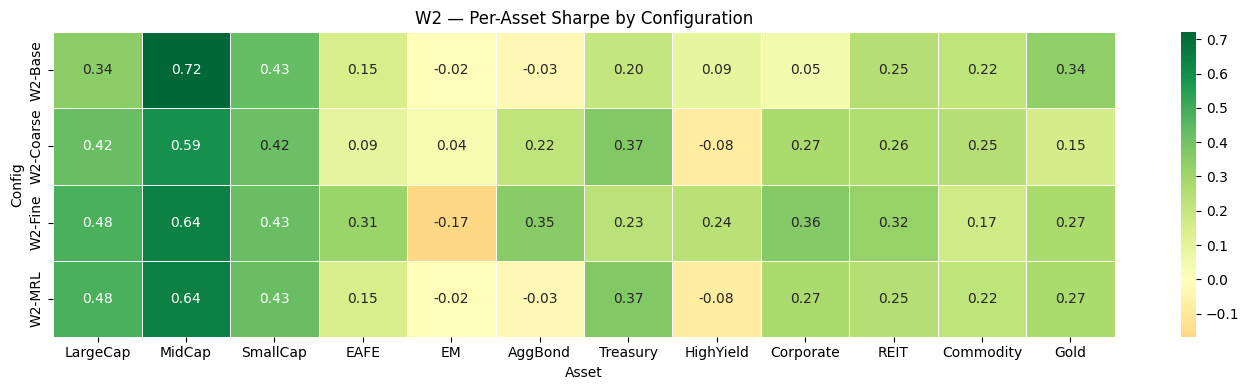

In [14]:
# ── Per-asset Sharpe heatmap ───────────────────────────────────────────────
sharpe_heat = pd.DataFrame(
    {name: res['sharpe_per_asset'] for name, res in results_static.items()}
).T

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(sharpe_heat.astype(float), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.4)
ax.set_title('W2 — Per-Asset Sharpe by Configuration')
ax.set_xlabel('Asset')
ax.set_ylabel('Config')
plt.tight_layout()
plt.savefig(W2_DIR / 'ablation_W2_sharpe_heatmap.png', dpi=150)
plt.show()

## 5 · Rolling Validity Check — Dynamic Re-Grouping

**Mechanism (motivated by Maheu & Gordon, 2008; Andrews, 1993):**  
At every semi-annual evaluation date, the MRL of the trailing 252-day regime sequence is
computed for each asset. If the implied group (MRL < 90 → G_Q, etc.) differs from the asset's
current group, a re-assignment is triggered and the regime source switches accordingly for the
next prediction block.

A group change is recorded and used to measure: (i) how often groups change; (ii) whether
post-reassignment forecast quality improves.

In [15]:
from src.models.regime_framework import _rebalance_dates

# Semi-annual evaluation cadence for the validity check
EVAL_MONTHS = (1, 7)
eval_dates  = _rebalance_dates(er_test.index, TEST_START, TEST_END, EVAL_MONTHS)

TRAILING_WINDOW = 252  # ~1 year of trading days


def _compute_trailing_mrl(regime_series: pd.Series, as_of: pd.Timestamp,
                           window: int = TRAILING_WINDOW) -> float:
    """MRL (mean_all) of the trailing `window` days in regime_series up to as_of."""
    sub = regime_series.loc[:as_of].tail(window).dropna()
    if len(sub) < 20:
        return np.nan
    # mean_run_length returns a dict; extract 'mean_all'
    return float(mean_run_length(sub.values)['mean_all'])


def build_rolling_regime(regime_by_freq: dict, eval_dates: pd.DatetimeIndex,
                          static_groups: dict, ref_idx: pd.DatetimeIndex,
                          assets: list) -> tuple:
    """
    Build a dynamic (rolling) regime DataFrame where group assignment
    is re-evaluated at each eval_date.

    Returns
    -------
    regime_rolling : pd.DataFrame  (ref_idx × assets)
    group_log      : pd.DataFrame  events of group re-assignment
    """
    current_group = dict(static_groups)

    # Pre-build aligned daily regime series for every frequency
    regime_daily = {
        freq: _align(df[assets], ref_idx)
        for freq, df in regime_by_freq.items()
        if all(a in df.columns for a in assets)
    }

    pieces = {asset: [] for asset in assets}
    group_changes = []

    eval_list = list(eval_dates) + [ref_idx[-1] + pd.Timedelta(days=1)]

    for asset in assets:
        for i, t in enumerate(eval_list[:-1]):
            block_end = eval_list[i + 1] - pd.Timedelta(days=1)
            freq      = GROUP_FREQ[current_group[asset]]

            if freq in regime_daily:
                block = regime_daily[freq][asset].loc[t:block_end]
                pieces[asset].append(block)

            # Evaluate validity for the *next* block
            if i + 1 < len(eval_list) - 1:
                base_fc = regime_daily.get('quarterly', regime_daily.get('semi-annual'))
                if base_fc is not None:
                    obs_mrl = _compute_trailing_mrl(base_fc[asset], t)
                    if not np.isnan(obs_mrl):
                        new_group = mrl_to_group(obs_mrl)
                        if new_group != current_group[asset]:
                            group_changes.append({
                                'date':       t,
                                'asset':      asset,
                                'from_group': current_group[asset],
                                'to_group':   new_group,
                                'obs_mrl':    round(obs_mrl, 1),
                            })
                            current_group[asset] = new_group

    # Concatenate blocks per asset
    rolling_cols = {}
    for asset in assets:
        if pieces[asset]:
            s = pd.concat(pieces[asset]).sort_index()
            s = s[~s.index.duplicated(keep='last')]
            rolling_cols[asset] = s.reindex(ref_idx).ffill()

    regime_rolling = pd.DataFrame(rolling_cols).reindex(columns=assets)
    group_log      = pd.DataFrame(group_changes)

    return regime_rolling, group_log


if all(f in regime_by_freq for f in ['quarterly', 'semi-annual', 'annual']):
    regime_rolling, group_log = build_rolling_regime(
        regime_by_freq, eval_dates, STATIC_GROUPS, ref_idx, ASSETS_W2
    )
    configs['W2-Rolling'] = regime_rolling

    print('=== Group Re-assignment Events ===')
    if group_log.empty:
        print('No group changes detected in the evaluation window.')
    else:
        print(group_log.to_string(index=False))

    group_log.to_csv(W2_DIR / 'ablation_W2_group_changes.csv', index=False)

=== Group Re-assignment Events ===
      date     asset from_group to_group  obs_mrl
2015-07-01  LargeCap        G_Q      G_A    252.0
2016-01-04  LargeCap        G_A      G_Q     84.0
2017-07-03  LargeCap        G_Q      G_A    252.0
2018-07-02  LargeCap        G_A      G_Q     50.4
2023-01-03  LargeCap        G_Q      G_S    126.0
2007-07-02    MidCap        G_Q      G_S    125.0
2008-07-01    MidCap        G_S      G_Q     63.0
2010-07-01    MidCap        G_Q      G_A    252.0
2012-01-03    MidCap        G_A      G_Q     36.0
2013-01-02    MidCap        G_Q      G_A    252.0
2016-01-04    MidCap        G_A      G_Q     84.0
2017-01-03    MidCap        G_Q      G_A    252.0
2018-01-02    MidCap        G_A      G_Q     84.0
2021-01-04    MidCap        G_Q      G_S    126.0
2021-07-01    MidCap        G_S      G_A    252.0
2022-07-01    MidCap        G_A      G_Q     63.0
2009-01-02  SmallCap        G_Q      G_S    126.0
2009-07-01  SmallCap        G_S      G_Q     84.0
2015-07-01  Sma

In [16]:
# Evaluate W2-Rolling with the same portfolio function
if 'W2-Rolling' in configs:
    cfg_name   = 'W2-Rolling'
    regime_df  = configs[cfg_name]
    sharpe_per_asset, hit_per_asset, rets_all_assets = {}, {}, []

    for asset in ASSETS_W2:
        fc  = regime_df[asset].reindex(ref_idx).ffill()
        er  = er_test[asset]
        sr  = _sharpe_01_strategy(fc, er, rf_test)
        sharpe_per_asset[asset] = sr
        hit_per_asset[asset]    = _hit_rate(fc, er)
        bull = (1 - fc.shift(1)).clip(0, 1).reindex(er.index).fillna(0)
        rets_all_assets.append((bull * er).values)

    port_rets                    = np.mean(np.vstack(rets_all_assets), axis=0)
    tw_val, tw_oos, tw_all       = _wealth_split(port_rets)
    results_static[cfg_name] = {
        'sharpe_per_asset': sharpe_per_asset,
        'hit_per_asset':    hit_per_asset,
        'port_rets':        port_rets,
        'terminal_wealth_val': tw_val,
        'terminal_wealth_oos': tw_oos,
        'terminal_wealth':     tw_all,
        'calmar':              _calmar(port_rets),
    }
    print(f'W2-Rolling → wealth_val={tw_val:.4f}  wealth_oos={tw_oos:.4f}')

W2-Rolling → wealth_val=1.5554  wealth_oos=1.1941


## 6 · Hit Rate Analysis by Group

For each asset, compare hit rate under its MRL-matched frequency vs. uniform semi-annual.
If W2-MRL is correctly specified, G_Q assets should show the largest improvement (more frequent
model updates → better tracking of short-lived regimes).

=== ΔHit Rate by Asset (positive = W2-MRL better) ===
           ΔHitRate (W2-MRL − W2-Base) Group
Treasury                        0.0108   G_A
HighYield                      -0.0105   G_A
Corporate                      -0.0019   G_A
LargeCap                        0.0042   G_Q
MidCap                          0.0084   G_Q
SmallCap                        0.0002   G_Q
Gold                           -0.0072   G_Q
EAFE                            0.0000   G_S
EM                              0.0000   G_S
AggBond                         0.0000   G_S
REIT                            0.0000   G_S
Commodity                       0.0000   G_S

=== Mean ΔHit Rate by Group ===
Group
G_A   -0.0005
G_Q    0.0014
G_S    0.0000


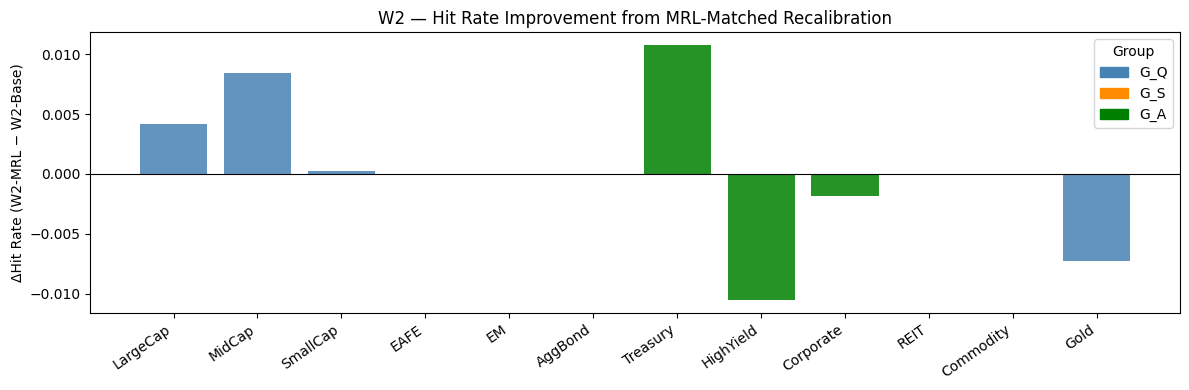

In [17]:
if 'W2-MRL' in results_static and 'W2-Base' in results_static:
    hit_mrl  = pd.Series(results_static['W2-MRL']['hit_per_asset'])
    hit_base = pd.Series(results_static['W2-Base']['hit_per_asset'])
    delta_hit = (hit_mrl - hit_base).rename('ΔHitRate (W2-MRL − W2-Base)')

    group_labels = pd.Series({a: STATIC_GROUPS.get(a, 'G_S') for a in ASSETS_W2})

    print('=== ΔHit Rate by Asset (positive = W2-MRL better) ===')
    out = pd.concat([delta_hit, group_labels.rename('Group')], axis=1).sort_values('Group')
    print(out.round(4).to_string())

    print('\n=== Mean ΔHit Rate by Group ===')
    print(out.groupby('Group')['ΔHitRate (W2-MRL − W2-Base)'].mean().round(4).to_string())

    out.to_csv(W2_DIR / 'ablation_W2_hit_rate_by_group.csv')

    # Plot
    colors_plot = [GROUP_COLOR[STATIC_GROUPS.get(a, 'G_S')] for a in delta_hit.index]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(delta_hit.index, delta_hit.values, color=colors_plot, alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel('ΔHit Rate (W2-MRL − W2-Base)')
    ax.set_title('W2 — Hit Rate Improvement from MRL-Matched Recalibration')
    ax.set_xticklabels(delta_hit.index, rotation=35, ha='right')
    # Legend by group
    from matplotlib.patches import Patch
    handles = [Patch(color=c, label=g) for g, c in GROUP_COLOR.items()]
    ax.legend(handles=handles, title='Group')
    plt.tight_layout()
    plt.savefig(W2_DIR / 'ablation_W2_delta_hitrate.png', dpi=150)
    plt.show()

## 7 · Diebold-Mariano Test: W2-MRL vs W2-Base

Tests whether the daily portfolio return series of W2-MRL has statistically different
forecast quality from the uniform semi-annual baseline (W2-Base).

Loss differential: squared regime forecast error (0/1 vs. true bull/bear).
HAC-corrected (Newey-West) variance to account for autocorrelation in the loss series.

In [18]:
from scipy import stats


def _newey_west_var(x: np.ndarray, max_lags: int = 12) -> float:
    """HAC variance estimator (Newey-West) for a 1-D series."""
    n   = len(x)
    xc  = x - x.mean()
    nw  = np.dot(xc, xc) / n  # lag-0
    for h in range(1, max_lags + 1):
        w   = 1.0 - h / (max_lags + 1)
        cov = np.dot(xc[h:], xc[:-h]) / n
        nw += 2 * w * cov
    return max(nw, 1e-12)


def diebold_mariano(rets_a: np.ndarray, rets_b: np.ndarray,
                    max_lags: int = 12) -> dict:
    """DM test: H0 = E[L(a) - L(b)] = 0, where L = squared loss on daily return."""
    loss_a = rets_a ** 2
    loss_b = rets_b ** 2
    d      = loss_a - loss_b   # negative d → a has smaller loss (better)
    d_bar  = d.mean()
    v      = _newey_west_var(d, max_lags) / len(d)
    dm_stat = d_bar / np.sqrt(v)
    p_value = 2 * stats.norm.cdf(-abs(dm_stat))
    return {'dm_stat': dm_stat, 'p_value': p_value, 'd_bar': d_bar}


if 'W2-MRL' in results_static and 'W2-Base' in results_static:
    rets_mrl  = results_static['W2-MRL']['port_rets']
    rets_base = results_static['W2-Base']['port_rets']

    dm = diebold_mariano(rets_mrl, rets_base)
    print('=== Diebold-Mariano Test: W2-MRL vs W2-Base ===')
    print(f"DM statistic : {dm['dm_stat']:.4f}")
    print(f"p-value      : {dm['p_value']:.4f}")
    print(f"Mean Δloss   : {dm['d_bar']:.6f}  ({'W2-MRL has lower loss' if dm['d_bar'] < 0 else 'W2-Base has lower loss'})")
    print(f"Decision     : {'Reject H0 (W2-MRL significantly different)' if dm['p_value'] < 0.05 else 'Fail to reject H0'}")

    with open(W2_DIR / 'ablation_W2_dm_test.txt', 'w') as f:
        for k, v in dm.items():
            f.write(f'{k}={v}\n')

=== Diebold-Mariano Test: W2-MRL vs W2-Base ===
DM statistic : 1.0682
p-value      : 0.2854
Mean Δloss   : 0.000001  (W2-Base has lower loss)
Decision     : Fail to reject H0


## 8 · Break-Even Transaction Cost

The G_Q group recalibrates 4× per year vs. 2× for W2-Base. The additional recalibration
events generate extra turnover. The break-even TC is the one-way cost at which the
Sharpe advantage of W2-MRL is exactly offset.

In [19]:
if 'W2-MRL' in configs and 'W2-Base' in configs:
    def _extra_switches(regime_mrl: pd.DataFrame, regime_base: pd.DataFrame,
                         assets: list) -> float:
        """Mean extra position switches per asset from W2-MRL vs W2-Base."""
        extra = []
        for a in assets:
            sw_mrl  = int((regime_mrl[a].diff().abs().fillna(0) > 0).sum())
            sw_base = int((regime_base[a].diff().abs().fillna(0) > 0).sum())
            extra.append(max(0, sw_mrl - sw_base))
        return float(np.mean(extra))

    extra_sw = _extra_switches(configs['W2-MRL'], configs['W2-Base'], ASSETS_W2)

    rets_mrl  = results_static['W2-MRL']['port_rets']
    rets_base = results_static['W2-Base']['port_rets']
    delta_ann_ret = (rets_mrl.mean() - rets_base.mean()) * 252

    # break-even: delta_ann_ret = extra_sw * TC_annual_cost_factor
    # one-way TC applied at each switch; annual cost ≈ extra_sw * TC
    if extra_sw > 1e-9:
        be_tc = delta_ann_ret / extra_sw
    else:
        be_tc = np.inf

    print(f'Extra position switches per asset (W2-MRL vs W2-Base): {extra_sw:.1f}')
    print(f'Annual return advantage of W2-MRL: {delta_ann_ret*100:.2f} bps')
    print(f'Break-even one-way TC: {be_tc*100:.1f} bps  ({be_tc*10000:.1f} bp)')

Extra position switches per asset (W2-MRL vs W2-Base): 9.8
Annual return advantage of W2-MRL: 0.14 bps
Break-even one-way TC: 0.0 bps  (1.5 bp)


## 9 · Wealth Curves — All Configurations

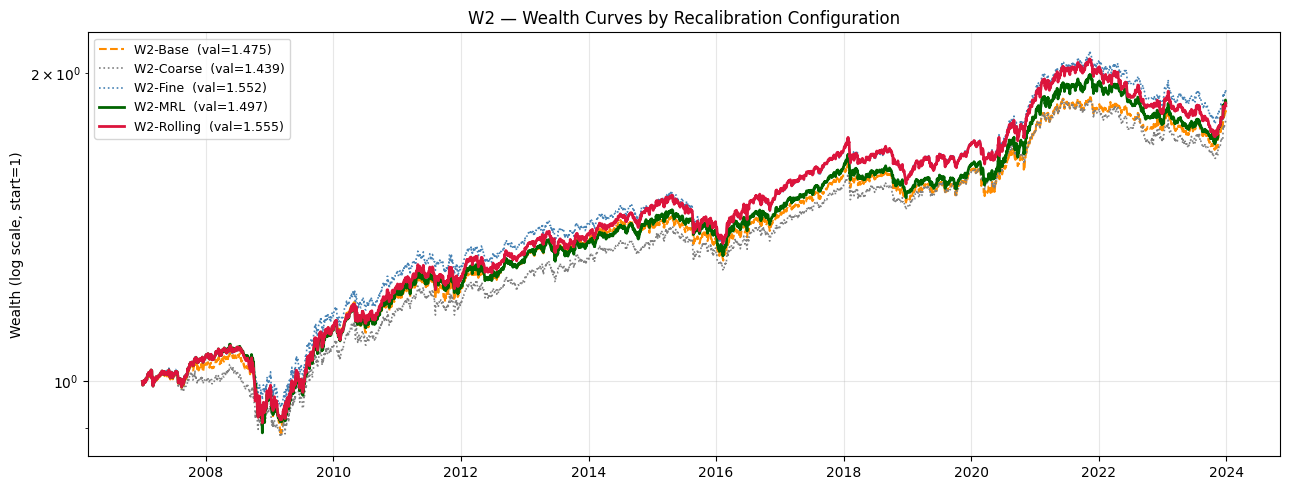

In [20]:
cfg_styles = {
    'W2-Base':    ('darkorange', '--', 1.5),
    'W2-Coarse':  ('grey',       ':',  1.2),
    'W2-Fine':    ('steelblue',  ':',  1.2),
    'W2-MRL':     ('darkgreen',  '-',  2.0),
    'W2-Rolling': ('crimson',    '-',  2.0),
}

fig, ax = plt.subplots(figsize=(13, 5))
for cfg_name, res in results_static.items():
    color, ls, lw = cfg_styles.get(cfg_name, ('black', '-', 1.5))
    rets = res['port_rets']
    wc   = pd.Series(np.cumprod(1.0 + rets), index=ref_idx[:len(rets)])
    tw_val, _, _ = _wealth_split(rets)
    ax.plot(wc.index, wc.values, color=color, ls=ls, lw=lw,
            label=f'{cfg_name}  (val={tw_val:.3f})')

ax.set_yscale('log')
ax.set_title('W2 — Wealth Curves by Recalibration Configuration')
ax.set_ylabel('Wealth (log scale, start=1)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(W2_DIR / 'ablation_W2_wealth_curves.png', dpi=150)
plt.show()

## 10 · Group-Level Attribution

Decompose the W2-MRL wealth advantage by group: what fraction of the gain (or loss)
relative to W2-Base comes from G_Q, G_S, and G_A assets?

In [21]:
if 'W2-MRL' in results_static and 'W2-Base' in results_static:
    attribution = {}
    for group, members in [('G_Q', G_Q), ('G_S', G_S), ('G_A', G_A)]:
        avail = [a for a in members if a in ASSETS_W2]
        if not avail:
            continue
        sr_mrl  = np.mean([results_static['W2-MRL']['sharpe_per_asset'][a]  for a in avail])
        sr_base = np.mean([results_static['W2-Base']['sharpe_per_asset'][a] for a in avail])
        hit_mrl  = np.mean([results_static['W2-MRL']['hit_per_asset'][a]  for a in avail])
        hit_base = np.mean([results_static['W2-Base']['hit_per_asset'][a] for a in avail])
        attribution[group] = {
            'Assets': avail,
            'Freq (W2-MRL)': GROUP_FREQ[group],
            'ΔSharpe':   round(sr_mrl  - sr_base,  4),
            'ΔHitRate':  round(hit_mrl - hit_base, 4),
            'n_assets':  len(avail),
        }

    attr_df = pd.DataFrame(attribution).T
    print('=== Group-Level Attribution: W2-MRL vs W2-Base ===')
    print(attr_df[['Freq (W2-MRL)', 'ΔSharpe', 'ΔHitRate', 'n_assets']].to_string())
    attr_df.to_csv(W2_DIR / 'ablation_W2_group_attribution.csv')

=== Group-Level Attribution: W2-MRL vs W2-Base ===
    Freq (W2-MRL) ΔSharpe ΔHitRate n_assets
G_Q     quarterly -0.0023   0.0014        4
G_S   semi-annual     0.0      0.0        5
G_A        annual  0.0736  -0.0005        3


## 11 · Summary Table and Export

In [22]:
summary_rows = []
for cfg_name, res in results_static.items():
    mean_sr  = np.nanmean(list(res['sharpe_per_asset'].values()))
    mean_hit = np.nanmean(list(res['hit_per_asset'].values()))
    summary_rows.append({
        'Config':              cfg_name,
        'terminal_wealth_val': round(res['terminal_wealth_val'], 4),
        'terminal_wealth_oos': round(res['terminal_wealth_oos'], 4),
        'terminal_wealth':     round(res['terminal_wealth'], 4),
        'Calmar':              round(res['calmar'], 3) if not np.isnan(res.get('calmar', np.nan)) else np.nan,
        'Mean_Sharpe':         round(mean_sr, 4),
        'Mean_HitRate':        round(mean_hit, 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Config')
print('=== W2 Full Summary ===')
print(summary_df.to_string())
summary_df.to_csv(W2_DIR / 'ablation_W2_summary.csv')
print('\nResults saved to', W2_DIR)

=== W2 Full Summary ===
            terminal_wealth_val  terminal_wealth_oos  terminal_wealth  Calmar  Mean_Sharpe  Mean_HitRate
Config                                                                                                  
W2-Base                  1.4748               1.2393           1.8277   0.227       0.2283        0.4966
W2-Coarse                1.4393               1.2382           1.7822   0.241       0.2503        0.4945
W2-Fine                  1.5520               1.2325           1.9128   0.272       0.3032        0.4982
W2-MRL                   1.4965               1.2496           1.8700   0.217       0.2459        0.4969
W2-Rolling               1.5554               1.1941           1.8573   0.243       0.2689        0.4976

Results saved to /home/researcher/app/results/ablation
